In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mysql.connector

In [2]:
conn= mysql.connector.connect(host='localhost',user='root',password='root',database='store')

In [3]:
querry1='select * from orders_table'
querry2='select * from order_item'
querry3='select * from customers'
querry4='select * from payments'
querry5='select * from products'
querry6='select * from sellers'
querry7='select * from geolocation'
querry8='select * from order_value'



In [4]:
orders=pd.read_sql(querry1,conn)
order_item=pd.read_sql(querry2,conn)
customers=pd.read_sql(querry3,conn)
payments=pd.read_sql(querry4,conn)
products=pd.read_sql(querry5,conn)
sellers=pd.read_sql(querry6,conn)
geolocation=pd.read_sql(querry7,conn)
order_value=pd.read_sql(querry8,conn)

C:\ProgramData\Anaconda3\lib\site-packages\pandas\io\sql.py:762: UserWarning: pandas only support SQLAlchemy connectable(engine/connection) ordatabase string URI or sqlite3 DBAPI2 connectionother DBAPI2 objects are not tested, please consider using SQLAlchemy
  warnings.warn(
C:\ProgramData\Anaconda3\lib\site-packages\pandas\io\sql.py:762: UserWarning: pandas only support SQLAlchemy connectable(engine/connection) ordatabase string URI or sqlite3 DBAPI2 connectionother DBAPI2 objects are not tested, please consider using SQLAlchemy
  warnings.warn(
C:\ProgramData\Anaconda3\lib\site-packages\pandas\io\sql.py:762: UserWarning: pandas only support SQLAlchemy connectable(engine/connection) ordatabase string URI or sqlite3 DBAPI2 connectionother DBAPI2 objects are not tested, please consider using SQLAlchemy
  warnings.warn(
C:\ProgramData\Anaconda3\lib\site-packages\pandas\io\sql.py:762: UserWarning: pandas only support SQLAlchemy connectable(engine/connection) ordatabase string URI or sqli

In [5]:
orders[0:5]

,order_id,customer_id,order_status,order_purchase_date,order_purchase_time,order_approved_date,order_approved_time,order_delivered_carrier_date,order_delivered_carrier_time,order_delivered_customer_date,order_delivered_customer_time,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02,0 days 10:56:33,2017-10-02,0 days 11:07:15,2017-10-04,0 days 19:55:00,2017-10-10,0 days 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24,0 days 20:41:37,2018-07-26,0 days 03:24:27,2018-07-26,0 days 14:31:00,2018-08-07,0 days 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08,0 days 08:38:49,2018-08-08,0 days 08:55:23,2018-08-08,0 days 13:50:00,2018-08-17,0 days 18:06:29,2018-09-04
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18,0 days 19:28:06,2017-11-18,0 days 19:45:59,2017-11-22,0 days 13:39:59,2017-12-02,0 days 00:28:42,2017-12-15
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13,0 days 21:18:39,2018-02-13,0 days 22:20:29,2018-02-14,0 days 19:46:34,2018-02-16,0 days 18:17:02,2018-02-26


In [6]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 12 columns):
 #   Column                         Non-Null Count  Dtype          
---  ------                         --------------  -----          
 0   order_id                       99441 non-null  object         
 1   customer_id                    99441 non-null  object         
 2   order_status                   99441 non-null  object         
 3   order_purchase_date            99441 non-null  object         
 4   order_purchase_time            99441 non-null  timedelta64[ns]
 5   order_approved_date            99281 non-null  object         
 6   order_approved_time            99281 non-null  timedelta64[ns]
 7   order_delivered_carrier_date   97658 non-null  object         
 8   order_delivered_carrier_time   99441 non-null  timedelta64[ns]
 9   order_delivered_customer_date  96476 non-null  object         
 10  order_delivered_customer_time  99441 non-null  timedelta64[ns]
 11  or

In [7]:
orders["order_purchase_date"]=pd.to_datetime(orders["order_purchase_date"])
orders["order_approved_date"]=pd.to_datetime(orders["order_approved_date"])
orders["order_delivered_carrier_date"]=pd.to_datetime(orders["order_delivered_carrier_date"]) 
orders["order_delivered_customer_date"]=pd.to_datetime(orders["order_delivered_customer_date"]) 
orders["order_estimated_delivery_date"]=pd.to_datetime(orders["order_estimated_delivery_date"]) 

In [8]:
order_item

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,shipping_limit_time
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19,58.90,13.29,0 days 09:45:35
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03,239.90,19.93,0 days 11:05:13
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18,199.00,17.87,0 days 14:48:30
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15,12.99,12.79,0 days 10:10:18
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13,199.90,18.14,0 days 13:57:51
...,...,...,...,...,...,...,...,...
112645,fffc94f6ce00a00581880bf54a75a037,1,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,2018-05-02,299.99,43.41,0 days 04:11:01
112646,fffcd46ef2263f404302a634eb57f7eb,1,32e07fd915822b0765e448c4dd74c828,f3c38ab652836d21de61fb8314b69182,2018-07-20,350.00,36.53,0 days 04:31:48
112647,fffce4705a9662cd70adb13d4a31832d,1,72a30483855e2eafc67aee5dc2560482,c3cfdc648177fdbbbb35635a37472c53,2017-10-30,99.90,16.95,0 days 17:14:25
112648,fffe18544ffabc95dfada21779c9644f,1,9c422a519119dcad7575db5af1ba540e,2b3e4a2a3ea8e01938cabda2a3e5cc79,2017-08-21,55.99,8.72,0 days 00:04:32


In [9]:
order_item.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 8 columns):
 #   Column               Non-Null Count   Dtype          
---  ------               --------------   -----          
 0   order_id             112650 non-null  object         
 1   order_item_id        112650 non-null  int64          
 2   product_id           112650 non-null  object         
 3   seller_id            112650 non-null  object         
 4   shipping_limit_date  112650 non-null  object         
 5   price                112650 non-null  float64        
 6   freight_value        112650 non-null  float64        
 7   shipping_limit_time  112650 non-null  timedelta64[ns]
dtypes: float64(2), int64(1), object(4), timedelta64[ns](1)
memory usage: 6.9+ MB


In [10]:
order_item["shipping_limit_date"]=pd.to_datetime(order_item["shipping_limit_date"]) 

In [11]:
customers

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP\r
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP\r
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP\r
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP\r
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP\r
...,...,...,...,...,...
99436,17ddf5dd5d51696bb3d7c6291687be6f,1a29b476fee25c95fbafc67c5ac95cf8,3937,sao paulo,SP\r
99437,e7b71a9017aa05c9a7fd292d714858e8,d52a67c98be1cf6a5c84435bd38d095d,6764,taboao da serra,SP\r
99438,5e28dfe12db7fb50a4b2f691faecea5e,e9f50caf99f032f0bf3c55141f019d99,60115,fortaleza,CE\r
99439,56b18e2166679b8a959d72dd06da27f9,73c2643a0a458b49f58cea58833b192e,92120,canoas,RS\r


In [12]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


In [13]:
products

,product_id,product_category,product_name_length,product_description_length,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumery,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,Art,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,sport leisure,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,babies,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,housewares,37.0,402.0,4.0,625.0,20.0,17.0,13.0
...,...,...,...,...,...,...,...,...,...
32946,a0b7d5a992ccda646f2d34e418fff5a0,Furniture Decoration,45.0,67.0,2.0,12300.0,40.0,40.0,40.0
32947,bf4538d88321d0fd4412a93c974510e6,Construction Tools Illumination,41.0,971.0,1.0,1700.0,16.0,19.0,16.0
32948,9a7c6041fa9592d9d9ef6cfe62a71f8c,bed table bath,50.0,799.0,1.0,1400.0,27.0,7.0,27.0
32949,83808703fc0706a22e264b9d75f04a2e,computer accessories,60.0,156.0,2.0,700.0,31.0,13.0,20.0


In [14]:
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category            32951 non-null  object 
 2   product_name_length         32950 non-null  float64
 3   product_description_length  32950 non-null  float64
 4   product_photos_qty          32950 non-null  float64
 5   product_weight_g            32950 non-null  float64
 6   product_length_cm           32950 non-null  float64
 7   product_height_cm           32950 non-null  float64
 8   product_width_cm            32950 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


In [15]:
products.fillna(0,inplace=True)

In [16]:
convert_to_int=products[['product_name_length','product_description_length','product_photos_qty','product_weight_g','product_length_cm','product_height_cm','product_width_cm']]

In [17]:
products[['product_name_length','product_description_length','product_photos_qty','product_weight_g','product_length_cm','product_height_cm','product_width_cm']]=convert_to_int.convert_dtypes(int)

Basic Question

----Q1 List all unique cities where customers are located.

In [18]:
customers.head(10)

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP\r
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP\r
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP\r
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP\r
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP\r
5,879864dab9bc3047522c92c82e1212b8,4c93744516667ad3b8f1fb645a3116a4,89254,jaragua do sul,SC\r
6,fd826e7cf63160e536e0908c76c3f441,addec96d2e059c80c30fe6871d30d177,4534,sao paulo,SP\r
7,5e274e7a0c3809e14aba7ad5aae0d407,57b2a98a409812fe9618067b6b8ebe4f,35182,timoteo,MG\r
8,5adf08e34b2e993982a47070956c5c65,1175e95fb47ddff9de6b2b06188f7e0d,81560,curitiba,PR\r
9,4b7139f34592b3a31687243a302fa75b,9afe194fb833f79e300e37e580171f22,30575,belo horizonte,MG\r


In [19]:
customer_city=customers['customer_city'].value_counts().reset_index(name='total_customers')

In [20]:
customer_city=customers['customer_city'].value_counts().reset_index(name='total_customers')

In [21]:
top10_city=customer_city.sort_values('total_customers',ascending=False).head(10)

In [22]:
pd.DataFrame(data=top10_city.loc[:,'index']).rename(columns={'index':'Top10_city'})

,Top10_city
0,sao paulo
1,rio de janeiro
2,belo horizonte
3,brasilia
4,curitiba
5,campinas
6,porto alegre
7,salvador
8,guarulhos
9,sao bernardo do campo


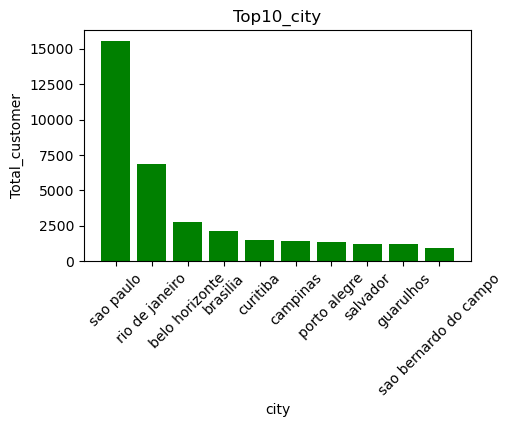

In [23]:
x=top10_city['index']
y=top10_city['total_customers']
plt.figure(figsize=(5,3))
plt.bar(x,y,color='g')
plt.title('Top10_city')
plt.xlabel('city')
plt.ylabel('Total_customer')
plt.xticks(rotation=45)

plt.show()

---Q2 Count the number of orders placed in 2017.

In [24]:
m1=orders['order_purchase_date'].dt.year==2017

In [25]:
orders[m1]['order_id'].count()

45101

---Q3 Find the total sales per category. 

In [26]:
merge_ot_pr=order_item.merge(products,on='product_id',how='inner')

In [27]:
tp_per_order=order_item.groupby('order_id')['price'].sum().reset_index(name='total_price')

In [28]:
tpv_per_order=pd.DataFrame(tp_per_order).merge(order_value,on='order_id',how='inner')

In [29]:
full_order_item=merge_ot_pr.merge(tpv_per_order,on='order_id',how='inner')

In [30]:
full_order_item['productID_wise_revenue']=(full_order_item['price']/full_order_item['total_price'])*full_order_item['total_value']

In [31]:
category_wise_rev=full_order_item.groupby('product_category')['productID_wise_revenue'].sum().reset_index(name='category_rev').sort_values('category_rev', ascending=False)

In [32]:
top10_category=category_wise_rev.head(10)

In [33]:
top10_category

,product_category,category_rev
30,HEALTH BEAUTY,1.437724e+06
46,Watches present,1.298805e+06
50,bed table bath,1.241370e+06
69,sport leisure,1.147149e+06
54,computer accessories,1.051081e+06
24,Furniture Decoration,8.994773e+05
62,housewares,7.720821e+05
13,Cool Stuff,7.044889e+05
48,automotive,6.785357e+05
28,Garden tools,5.793928e+05


In [34]:
pd.options.display.float_format='{:,.0f}'.format

In [35]:
top10_category[['product_category','category_rev']]

,product_category,category_rev
30,HEALTH BEAUTY,"1,437,724"
46,Watches present,"1,298,805"
50,bed table bath,"1,241,370"
69,sport leisure,"1,147,149"
54,computer accessories,"1,051,081"
24,Furniture Decoration,"899,477"
62,housewares,"772,082"
13,Cool Stuff,"704,489"
48,automotive,"678,536"
28,Garden tools,"579,393"


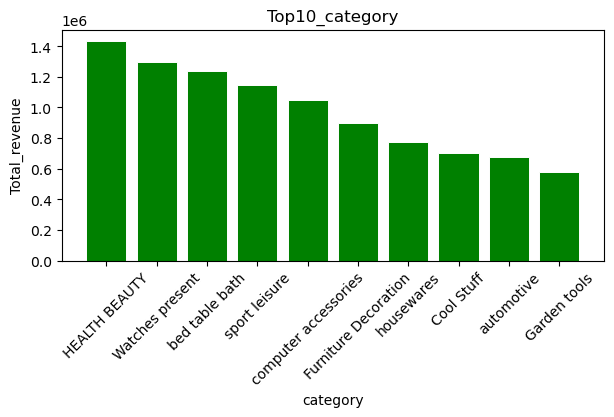

In [36]:
x1=top10_category['product_category']
y1=top10_category['category_rev']
plt.figure(figsize=(7,3))
plt.bar(x1,y1,color='g',width=0.8, edgecolor="white", linewidth=0.7)
plt.title('Top10_category')
plt.xlabel('category')
plt.ylabel('Total_revenue')
plt.xticks(rotation=45)
plt.show()


----Q4 Calculate the percentage of orders that were paid in installments.


In [37]:
realorder_payment=order_value.merge(payments,on='order_id',how='inner')

In [38]:
m2=realorder_payment.loc[:,'payment_installments']>1

In [39]:
pay_in_install=realorder_payment[m2]

In [40]:
round((pay_in_install['order_id'].nunique()/realorder_payment['order_id'].nunique())*100,1)

51.5

---Q5 Count the number of customers from each state.

In [41]:
merge_c_ot=orders.merge(customers,on='customer_id',how='inner')

In [42]:
m3=~merge_c_ot.loc[:,'order_status'].isin(['canceled','unavailable']) 

In [43]:
real_ot_c=merge_c_ot[m3]

In [44]:
state_wise_cust=real_ot_c.groupby(['customer_state'])['customer_unique_id'].nunique().reset_index(name='total_customers').sort_values('total_customers',ascending=False)

In [45]:
state_wise_cust['customer_state']=state_wise_cust['customer_state'].str.replace('\r','')

In [46]:
top10_state=state_wise_cust.head(10)

In [47]:
top10_state

,customer_state,total_customers
25,SP,39749
18,RJ,12242
10,MG,11134
22,RS,5234
17,PR,4825
23,SC,3502
4,BA,3244
6,DF,2058
7,ES,1950
8,GO,1934


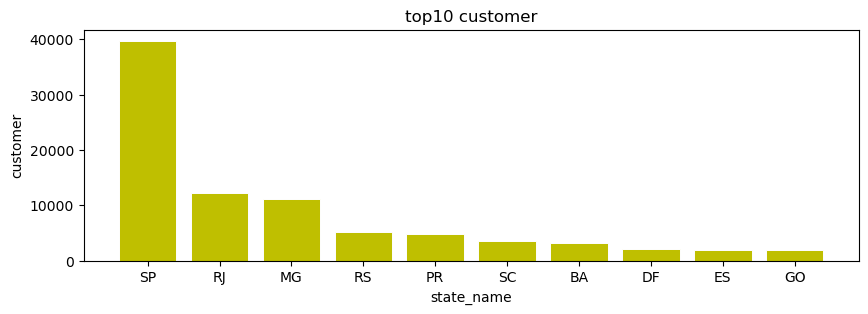

In [48]:
x2=top10_state['customer_state']
y2=top10_state['total_customers']
plt.figure(figsize=(10,3))
plt.bar(x2,y2,color='y',width=0.8, edgecolor="white",linewidth=0.7)
plt.title('top10 customer')
plt.xlabel('state_name')
plt.ylabel('customer')
plt.show()


Intermediate_ques

---Q1 Calculate the number of orders per month in 2018

In [49]:
import calendar

In [50]:
m4=real_ot_c['order_purchase_date'].dt.year==2018

In [51]:
orders_2018=real_ot_c[m4]

In [52]:
per_month_orders=orders_2018.groupby(orders_2018['order_purchase_date'].dt.month)['order_id'].nunique().reset_index(name='Total_orders_2018')

In [53]:
def month(x):
    if x==1:
        return "Jan"
    elif x==2:
        return "Feb"
    elif x==3:
        return "Mar"
    elif x==4:
        return "Apr"
    elif x==5:
        return "May"
    elif x==6:
        return "Jun"
    elif x==7:
        return "Jul"
    elif x==8:
        return "Aug"
    else: 
        return "Sep"
     
    

In [54]:
per_month_orders['Month']=per_month_orders['order_purchase_date'].apply(month)

In [55]:
per_month_orders[['Month','Total_orders_2018']]

,Month,Total_orders_2018
0,Jan,7187
1,Feb,6625
2,Mar,7168
3,Apr,6919
4,May,6833
5,Jun,6145
6,Jul,6233
7,Aug,6421
8,Sep,1


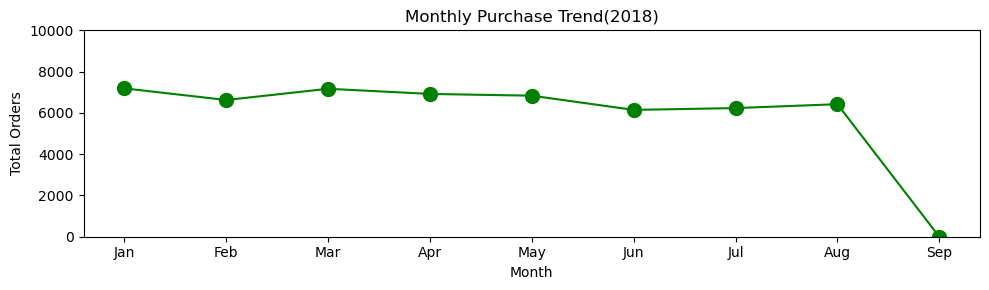

In [56]:
x3=per_month_orders['Month']
y3=per_month_orders['Total_orders_2018']
plt.figure(figsize=(10,3))
plt.plot(x3,y3,color='g',marker='o',markersize=10)
plt.ylim(0,10000)
plt.title('Monthly Purchase Trend(2018)')
plt.xlabel('Month')
plt.ylabel('Total Orders')
plt.tick_params(axis='x')
plt.tight_layout()
plt.show()


---Q2 Find the average number of products per order, grouped by customer city. 

In [57]:
all_real_tables=real_ot_c.merge(order_item,on='order_id',how='inner').merge(products,on='product_id',how='inner').merge(order_value,on='order_id',how='inner').merge(sellers,on='seller_id',how='inner')

In [58]:
city_wise_order=all_real_tables.groupby(['customer_city','order_id'])['product_id'].count().reset_index()

In [59]:
city_wise_avg_item=city_wise_order.groupby('customer_city')['product_id'].mean().reset_index(name='per_order_item').sort_values('per_order_item',ascending=False)

In [60]:
city_wise_avg_item

,customer_city,per_order_item
2619,padre carvalho,7
907,celso ramos,6
1154,datas,6
756,candido godoi,6
2264,matias olimpio,5
...,...,...
1661,independencia,1
1662,indiana,1
1663,indianopolis,1
1664,indiapora,1


In [61]:
top10_city=city_wise_avg_item.head(10)

In [62]:
top10_city

,customer_city,per_order_item
2619,padre carvalho,7
907,celso ramos,6
1154,datas,6
756,candido godoi,6
2264,matias olimpio,5
2395,morro de sao paulo,4
955,cidelandia,4
2816,picarra,4
1146,curralinho,4
3820,teixeira soares,4


<AxesSubplot:xlabel='per_order_item', ylabel='customer_city'>

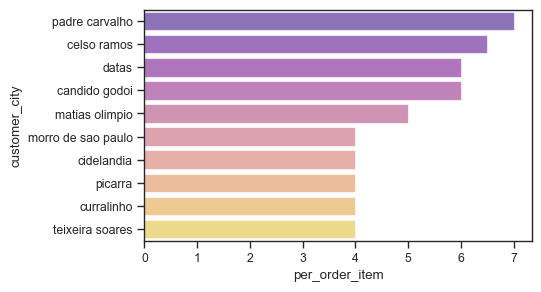

In [63]:
plt.figure(figsize=(5,3))
sns.set_style('ticks')
sns.set_context('paper')
sns.barplot(data=top10_city,x='per_order_item',y='customer_city',alpha=0.6,palette='plasma')


---Q3 Calculate the percentage of total revenue contributed by each product category


In [64]:
price_each_order=all_real_tables.groupby(['order_id'])['price'].sum().reset_index(name='total_price')

In [65]:
price_each_order

,order_id,total_price
0,00010242fe8c5a6d1ba2dd792cb16214,59
1,00018f77f2f0320c557190d7a144bdd3,240
2,000229ec398224ef6ca0657da4fc703e,199
3,00024acbcdf0a6daa1e931b038114c75,13
4,00042b26cf59d7ce69dfabb4e55b4fd9,200
...,...,...
98193,fffc94f6ce00a00581880bf54a75a037,300
98194,fffcd46ef2263f404302a634eb57f7eb,350
98195,fffce4705a9662cd70adb13d4a31832d,100
98196,fffe18544ffabc95dfada21779c9644f,56


In [66]:
df1=all_real_tables.merge(price_each_order ,on='order_id',how='inner')

In [67]:
df1['product_rev']=(df1['price']/df1['total_price'])*df1['total_value']

In [68]:
category_revenue=df1.groupby('product_category')['product_rev'].sum().reset_index(name='category_revenue').sort_values('category_revenue',ascending=False)

In [69]:
category_revenue['revenue_percent']=round((category_revenue['category_revenue']/category_revenue['category_revenue'].sum())*100,1)

In [70]:
top10_category=category_revenue.head(10)

In [71]:
top10_category

,product_category,category_revenue,revenue_percent
30,HEALTH BEAUTY,"1,437,724",9
46,Watches present,"1,298,805",8
50,bed table bath,"1,241,370",8
69,sport leisure,"1,147,149",7
54,computer accessories,"1,051,081",7
24,Furniture Decoration,"899,477",6
62,housewares,"772,082",5
13,Cool Stuff,"704,489",4
48,automotive,"678,536",4
28,Garden tools,"579,393",4


In [72]:
top10_category[['product_category','revenue_percent']]

,product_category,revenue_percent
30,HEALTH BEAUTY,9
46,Watches present,8
50,bed table bath,8
69,sport leisure,7
54,computer accessories,7
24,Furniture Decoration,6
62,housewares,5
13,Cool Stuff,4
48,automotive,4
28,Garden tools,4


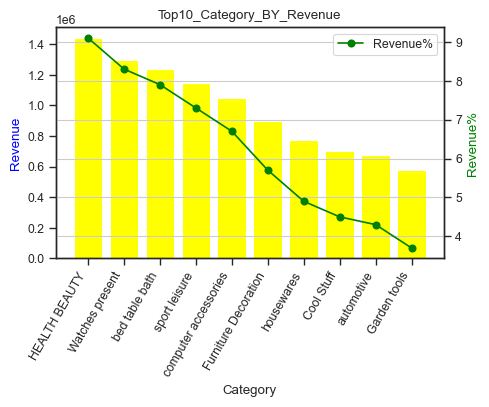

In [73]:
fig, ax1 = plt.subplots(figsize=(5,3))

# First axis (Orders as bar)
ax1.bar(top10_category['product_category'],top10_category['category_revenue'], color='yellow', label='Revenue')
ax1.set_xlabel("Category")
ax1.set_ylabel("Revenue", color='blue')

# Second axis (Revenue as line)
ax2 = ax1.twinx()
ax2.plot(top10_category['product_category'],top10_category['revenue_percent'], color='green', marker='o', label='Revenue%')
ax2.set_ylabel("Revenue%", color='green')
plt.title("Top10_Category_BY_Revenue")
plt.xticks(rotation=90)
plt.grid(True)
plt.legend(loc='upper right')
plt.setp(ax1.get_xticklabels(),rotation=60,ha='right')
plt.show()


---Q4 Identify the correlation between product price and the number of times a product has been purchased.

In [74]:
df=all_real_tables.groupby('product_id').agg(avg_price=('price','mean'),total_purchases=('product_id','count')).reset_index()      

In [75]:
df.sort_values('total_purchases',ascending=False).head(10).rename(columns={'product_id':'top_selling_product'})


,top_selling_product,avg_price,total_purchases
21959,aca2eb7d00ea1a7b8ebd4e68314663af,71,527
19599,99a4788cb24856965c36a24e339b6058,88,487
8554,422879e10f46682990de24d770e7f83d,55,484
7314,389d119b48cf3043d311335e499d9c6b,55,391
7033,368c6c730842d78016ad823897a372db,54,388
10762,53759a2ecddad2bb87a079a1f1519f73,55,373
26858,d1c427060a0f73f6b889a5c7c61f2ac4,138,341
10789,53b36df67ebb7c41585e8d54d6772e08,117,323
2777,154e7e31ebfa092203795c972e5804a6,23,281
7997,3dd2a17168ec895c781a9191c1e95ad7,150,274


---Q5 Calculate the total revenue generated by each seller, and rank them by revenue.

In [76]:
tp_per_order

,order_id,total_price
0,00010242fe8c5a6d1ba2dd792cb16214,59
1,00018f77f2f0320c557190d7a144bdd3,240
2,000229ec398224ef6ca0657da4fc703e,199
3,00024acbcdf0a6daa1e931b038114c75,13
4,00042b26cf59d7ce69dfabb4e55b4fd9,200
...,...,...
98661,fffc94f6ce00a00581880bf54a75a037,300
98662,fffcd46ef2263f404302a634eb57f7eb,350
98663,fffce4705a9662cd70adb13d4a31832d,100
98664,fffe18544ffabc95dfada21779c9644f,56


In [77]:
all_real_tables.head(1)

,order_id,customer_id,order_status,order_purchase_date,order_purchase_time,order_approved_date,order_approved_time,order_delivered_carrier_date,order_delivered_carrier_time,order_delivered_customer_date,...,product_description_length,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,total_value,seller_zip_code_prefix,seller_city,seller_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02,0 days 10:56:33,2017-10-02,0 days 11:07:15,2017-10-04,0 days 19:55:00,2017-10-10,...,268,4,500,19,8,13,39,9350,maua,SP\r


In [78]:
each_seller_price=all_real_tables[['order_id','seller_id','price','total_value']].merge(tp_per_order,on='order_id',how='inner')

In [79]:
each_seller_price.head(2)

,order_id,seller_id,price,total_value,total_price
0,e481f51cbdc54678b7cc49136f2d6af7,3504c0cb71d7fa48d967e0e4c94d59d9,30,39,30
1,128e10d95713541c87cd1a2e48201934,3504c0cb71d7fa48d967e0e4c94d59d9,30,38,30


In [80]:
each_seller_price['seller_price']=(each_seller_price['price']/each_seller_price['total_price'])*each_seller_price['total_value']

In [81]:
revenue_by_seller=each_seller_price.groupby('seller_id')['seller_price'].sum().reset_index(name='seller_rev').sort_values('seller_rev',ascending=False)

In [82]:
top10_seller=revenue_by_seller.head(10)

In [83]:
top10_seller

,seller_id,seller_rev
849,4869f7a5dfa277a7dca6462dcf3b52b2,"249,453"
1515,7c67e1448b00f6e969d365cea6b010ab,"239,260"
873,4a3ca9315b744ce9f8e9374361493884,"236,504"
1000,53243585a1d6dc2643021fd1853d8905,"235,872"
2984,fa1c13f2614d7b5c4749cbc52fecda94,"202,887"
2611,da8622b14eb17ae2831f4ac5b9dab84a,"185,095"
1540,7e93a43ef30c4f03f38b393420bc753a,"178,865"
191,1025f0e2d44d7041d6cf58b6550e0bfa,"173,049"
1485,7a67c85e85bb2ce8582c35f2203ad736,"162,633"
1799,955fee9216a65b617aa5c0531780ce60,"160,534"


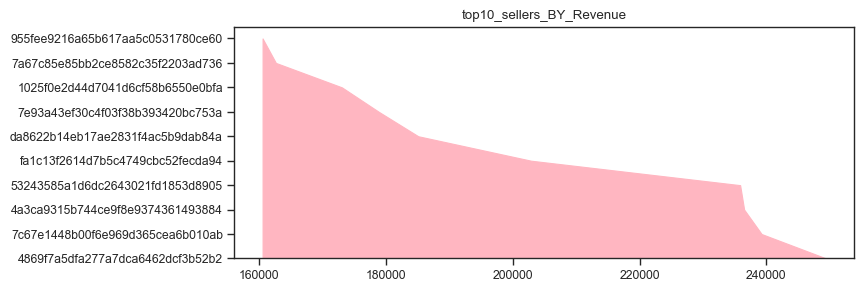

In [119]:
plt.figure(figsize=(8,3))
y5=top10_seller['seller_id']
x5=top10_seller['seller_rev']
plt.stackplot(x5,y5,color='lightpink')
plt.title('top10_sellers_BY_Revenue')
plt.show()

Advanced_ques

---Q1 Calculate the moving average of order values for each customer over their order history. 

In [85]:
orders.nunique()

order_id                         99441
customer_id                      99441
order_status                         8
order_purchase_date                634
order_purchase_time              50818
order_approved_date                611
order_approved_time              41746
order_delivered_carrier_date       547
order_delivered_carrier_time     37002
order_delivered_customer_date      645
order_delivered_customer_time    41100
order_estimated_delivery_date      459
dtype: int64

In [86]:
order_merge_py_c=orders.merge(order_value,on='order_id',how='inner').merge(customers,on='customer_id',how='inner')

In [87]:
order_merge_py_c.nunique()

order_id                         98206
customer_id                      98206
order_status                         6
order_purchase_date                613
order_purchase_time              50535
order_approved_date                609
order_approved_time              41494
order_delivered_carrier_date       547
order_delivered_carrier_time     36987
order_delivered_customer_date      645
order_delivered_customer_time    41098
order_estimated_delivery_date      446
total_value                       1626
customer_unique_id               94989
customer_zip_code_prefix         14964
customer_city                     4109
customer_state                      27
dtype: int64

In [88]:
order_merge_py_c.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 98206 entries, 0 to 98205
Data columns (total 17 columns):
 #   Column                         Non-Null Count  Dtype          
---  ------                         --------------  -----          
 0   order_id                       98206 non-null  object         
 1   customer_id                    98206 non-null  object         
 2   order_status                   98206 non-null  object         
 3   order_purchase_date            98206 non-null  datetime64[ns] 
 4   order_purchase_time            98206 non-null  timedelta64[ns]
 5   order_approved_date            98187 non-null  datetime64[ns] 
 6   order_approved_time            98187 non-null  timedelta64[ns]
 7   order_delivered_carrier_date   97582 non-null  datetime64[ns] 
 8   order_delivered_carrier_time   98206 non-null  timedelta64[ns]
 9   order_delivered_customer_date  96469 non-null  datetime64[ns] 
 10  order_delivered_customer_time  98206 non-null  timedelta64[ns]
 11  or

In [89]:
moving_avg_per_cust=order_merge_py_c.groupby(['customer_unique_id','order_purchase_date'])['total_value'].rolling(window=16,min_periods=1).mean().reset_index(name='moving_avg')

In [90]:
moving_avg_per_cust.sort_values('customer_unique_id').drop(columns='level_2')

,customer_unique_id,order_purchase_date,moving_avg
0,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10,142
1,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07,27
2,0000f46a3911fa3c0805444483337064,2017-03-10,86
3,0000f6ccb0745a6a4b88665a16c9f078,2017-10-12,44
4,0004aac84e0df4da2b147fca70cf8255,2017-11-14,197
...,...,...,...
98201,fffcf5a5ff07b0908bd4e2dbc735a684,2017-06-08,"2,067"
98202,fffea47cd6d3cc0a88bd621562a9d061,2017-12-10,85
98203,ffff371b4d645b6ecea244b27531430a,2017-02-07,112
98204,ffff5962728ec6157033ef9805bacc48,2018-05-02,134


In [91]:
moving_avg_per_cust['customer_unique_id'].value_counts()

8d50f5eadf50201ccdcedfb9e2ac8455    16
3e43e6105506432c953e165fb2acf44c     9
ca77025e7201e3b30c44b472ff346268     7
1b6c7548a2a1f9037c1fd3ddfed95f33     7
6469f99c1f9dfae7733b25662e7f1782     7
                                    ..
56509f7bc43892a0da09ee14f50a6f84     1
564feb90710b4f84399f931fa97ea704     1
564fb2956ed34f0a78c1cc37d731f3d9     1
564f89ca1f5371992bf1fb87a0331ac3     1
ffffd2657e2aad2907e67c3e9daecbeb     1
Name: customer_unique_id, Length: 94989, dtype: int64

In [92]:
m4=moving_avg_per_cust['customer_unique_id']=='8d50f5eadf50201ccdcedfb9e2ac8455'

In [93]:
moving_avg_per_cust[m4].drop(columns='level_2').rename(columns={'customer_unique_id':'Sample_customer'})

,Sample_customer,order_purchase_date,moving_avg
54120,8d50f5eadf50201ccdcedfb9e2ac8455,2017-05-15,23
54121,8d50f5eadf50201ccdcedfb9e2ac8455,2017-06-18,52
54122,8d50f5eadf50201ccdcedfb9e2ac8455,2017-07-18,22
54123,8d50f5eadf50201ccdcedfb9e2ac8455,2017-07-24,167
54124,8d50f5eadf50201ccdcedfb9e2ac8455,2017-08-05,82
54125,8d50f5eadf50201ccdcedfb9e2ac8455,2017-09-05,52
54126,8d50f5eadf50201ccdcedfb9e2ac8455,2017-10-18,38
54127,8d50f5eadf50201ccdcedfb9e2ac8455,2017-10-29,22
54128,8d50f5eadf50201ccdcedfb9e2ac8455,2017-11-22,22
54129,8d50f5eadf50201ccdcedfb9e2ac8455,2018-05-21,53


---Q2 Calculate the cumulative sales per month for each year.

In [94]:
order_merge_py_c['order_purchase_year']=order_merge_py_c['order_purchase_date'].dt.year

In [95]:
order_merge_py_c['order_purchase_month']=order_merge_py_c['order_purchase_date'].dt.month

In [96]:
per_month_sale=order_merge_py_c.groupby(['order_purchase_year','order_purchase_month'])['total_value'].sum().reset_index().sort_values(['order_purchase_year','order_purchase_month'])

In [97]:
cumulative_sale=per_month_sale.groupby('order_purchase_year')['total_value'].expanding().sum().reset_index(level=0)

In [98]:
cumulative_sale['order_purchase_month']=per_month_sale['order_purchase_month']

In [99]:
cumulative_sale[['order_purchase_year','order_purchase_month','total_value']].head(10)

,order_purchase_year,order_purchase_month,total_value
0,2016,9,136
1,2016,10,"51,791"
2,2016,12,"51,811"
3,2017,1,"137,045"
4,2017,2,"420,706"
5,2017,3,"846,469"
6,2017,4,"1,252,525"
7,2017,5,"1,835,525"
8,2017,6,"2,335,448"
9,2017,7,"2,914,384"


Text(0.5, 1.0, 'Cumulative_sales_per_month')

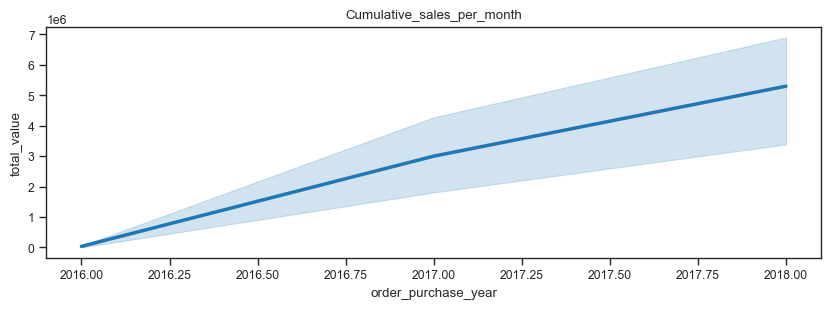

In [100]:
sns.set_context('paper')
plt.figure(figsize=(10,3))
sns.lineplot(data=cumulative_sale,x='order_purchase_year',y='total_value' ,palette="tab10", linewidth=2.5)
plt.title('Cumulative_sales_per_month')

---Q3 Calculate the year-over-year growth rate of total sales

In [101]:
year_sale=order_merge_py_c.groupby('order_purchase_year')['total_value'].sum().reset_index(name='total_sale')

In [102]:
year_sale['YOY_sale']=year_sale['total_sale'].pct_change() * 100

In [103]:
year_sale['YOY_sale']=year_sale['YOY_sale'].round(2).astype(str)+"%"

In [104]:
year_sale

,order_purchase_year,total_sale,YOY_sale
0,2016,"51,811",nan%
1,2017,"7,093,629",13591.36%
2,2018,"8,594,661",21.16%


In [105]:
order_merge_py_c.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 98206 entries, 0 to 98205
Data columns (total 19 columns):
 #   Column                         Non-Null Count  Dtype          
---  ------                         --------------  -----          
 0   order_id                       98206 non-null  object         
 1   customer_id                    98206 non-null  object         
 2   order_status                   98206 non-null  object         
 3   order_purchase_date            98206 non-null  datetime64[ns] 
 4   order_purchase_time            98206 non-null  timedelta64[ns]
 5   order_approved_date            98187 non-null  datetime64[ns] 
 6   order_approved_time            98187 non-null  timedelta64[ns]
 7   order_delivered_carrier_date   97582 non-null  datetime64[ns] 
 8   order_delivered_carrier_time   98206 non-null  timedelta64[ns]
 9   order_delivered_customer_date  96469 non-null  datetime64[ns] 
 10  order_delivered_customer_time  98206 non-null  timedelta64[ns]
 11  or

---Q4 Calculate the retention rate of customers, defined as the percentage of customers who make another purchase within 6 months of their first purchase.

In [106]:
first_purchase=order_merge_py_c.groupby('customer_unique_id')['order_purchase_date'].min().reset_index(name='first_purchase')

In [107]:
customer_retention=order_merge_py_c.merge(first_purchase,on='customer_unique_id',how='inner')

In [108]:
customer_retention['repeat_purchase']=customer_retention['order_purchase_date']-customer_retention['first_purchase']

In [109]:
customer_retention['repeat_purchase']=customer_retention['repeat_purchase'].dt.days

In [110]:
no_of_retention=customer_retention[(customer_retention['repeat_purchase']<=180) & (customer_retention['repeat_purchase']>0)]['customer_unique_id'].nunique()

In [111]:
total_customer=customers['customer_unique_id'].nunique()

In [112]:
round((no_of_retention/total_customer)*100,4)

1.6307

---Q5 Identify the top 3 customers who spent the most money in each year.

In [113]:
customer_rev=order_merge_py_c.groupby(['order_purchase_year','customer_unique_id'])['total_value'].sum().reset_index(name='Total_rev')

In [114]:
customer_rev['ranking']=customer_rev.groupby(['order_purchase_year'])['Total_rev'].rank(ascending=False)

In [115]:
YOY_top_customer=customer_rev[customer_rev['ranking']<=3].sort_values(['order_purchase_year','ranking'])

In [116]:
YOY_top_customer[['order_purchase_year','customer_unique_id']].rename(columns={'customer_unique_id':'Top3_customers'})

,order_purchase_year,Top3_customers
286,2016,fdaa290acb9eeacb66fa7f979baa6803
79,2016,40b41ade17bb2121b576b07e25ce622b
230,2016,cfbb7c1c3d613d974eef515b180e2c9b
2021,2017,0a0a92112bd4c708ca5fde585afaa872
37039,2017,da122df9eeddfedc1dc1f5349a1a690c
37409,2017,dc4802a71eae9be1dd28f5d788ceb526
67559,2018,763c8b1c9c68a0229c42c9fc6f662b93
57593,2018,459bef486812aa25204be022145caa62
58277,2018,48e1ac109decbb87765a3eade6854098


Text(0.5, 1.0, 'YOY_top_customer')

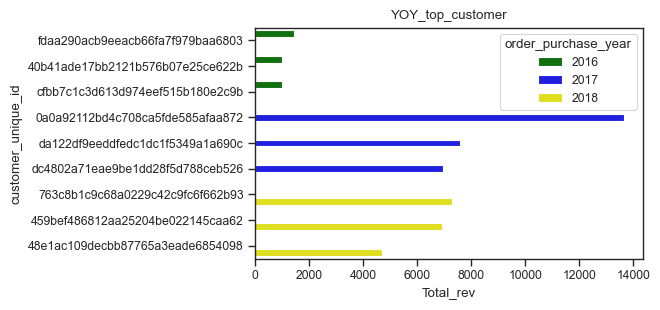

In [117]:
plt.figure(figsize=(5,3))
sns.barplot(data=YOY_top_customer,x='Total_rev',y='customer_unique_id',hue='order_purchase_year',palette=['green','blue','yellow'])
plt.title('YOY_top_customer')